In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import numpy as np
from pyproj import Transformer
from shapely.geometry import Point
import rasterio
import rioxarray
from scipy.spatial import cKDTree

In [ ]:
# Load Thailand map and get bounds
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap.crs = 'epsg:4326'
bounds = thailandmap.union_all().bounds
min_lon, max_lon, max_lat, min_lat = bounds[0], bounds[2], bounds[1], bounds[3]

: 

In [3]:
# Load land cover suitability indices
xr_landuse_si = xr.open_dataset('Output\\xr_SI_Landcover.nc')

# Create SI variables based on distance thresholds
dist = xr_distances

# SI calculations using vectorized operations
xr_si = xr.Dataset()

# BGEC and Biomass: 0 if < 500m + resolution, else 3
threshold_bgec_biomass = 500 + lccs_resolution
xr_si['SI_BGEC'] = xr.where(dist < threshold_bgec_biomass, 0, 3)
xr_si['SI_Biomass'] = xr.where(dist < threshold_bgec_biomass, 0, 3)

# Solar and Wind: 0 if < 400m + resolution, else 3
threshold_solar_wind = 400 + lccs_resolution
xr_si['SI_Solar'] = xr.where(dist < threshold_solar_wind, 0, 3)
xr_si['SI_Wind'] = xr.where(dist < threshold_solar_wind, 0, 3)

# BGWW: 0 if < 500m + resolution, else 3
xr_si['SI_BGWW'] = xr.where(dist < threshold_bgec_biomass, 0, 3)

# MSW and IEW: tiered thresholds
threshold_msw1 = 300 + lccs_resolution
threshold_msw2 = 600 + lccs_resolution
threshold_msw3 = 900 + lccs_resolution
xr_si['SI_MSW'] = xr.where(dist < threshold_msw1, 0,
                          xr.where(dist < threshold_msw2, 1,
                                  xr.where(dist < threshold_msw3, 2, 3)))

xr_si['SI_IEW'] = xr_si['SI_MSW'].copy()  # Same thresholds as MSW

# Mask with land cover SI (set to 0 where land cover SI is 0)
for var in ['SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']:
    xr_si[var] = xr.where(xr_landuse_si[var] == 0, 0, xr_si[var])

print(xr_si)

<xarray.Dataset> Size: 447MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


In [4]:
# Save to NetCDF
xr_si.to_netcdf(path='Output\\xr_SI_Distancetowetland.nc')
print("Saved xr_SI_Distancetowetland.nc")
print(xr_si)

Saved xr_SI_Distancetowetland.nc
<xarray.Dataset> Size: 447MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


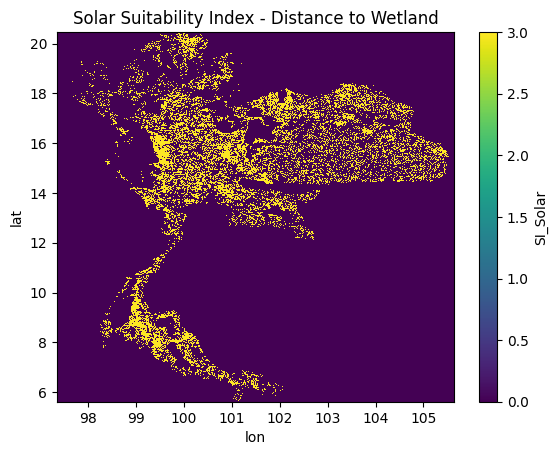

In [5]:
xr_si['SI_Solar'].plot()
plt.title('Solar Suitability Index - Distance to Wetland')
plt.show()

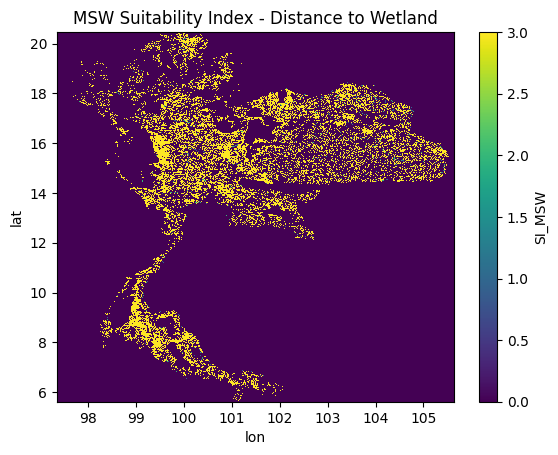

In [6]:
xr_si = xr.open_dataset("Output//xr_SI_Distancetowetland.nc")
xr_si['SI_MSW'].plot()
plt.title('MSW Suitability Index - Distance to Wetland')
plt.show()